# Homework 6 Code File

In [1]:
import arviz as az
import pandas as pd
import numpy as np
import pymc as pm
from pymc.math import exp
import matplotlib.pyplot as plt
import pytensor.tensor as pt
from pytensor.tensor.variable import TensorVariable
from itertools import combinations

rng = np.random.default_rng(6420)

In [5]:
# Load trace from nc file
trace_bcf = az.from_netcdf(f"ISYE6420/Project/bcf_joint_trace_with_intercept_ZINB.nc")
az.summary(trace_bcf, var_names=["kappa", "psi", "intercept"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,0.977,0.215,0.630,1.384,0.013,0.007,205.0,612.0,1.03
psi,0.685,0.064,0.562,0.797,0.005,0.002,145.0,389.0,1.03
intercept,-2.212,0.325,-2.800,-1.614,0.117,0.058,8.0,18.0,1.52


## Question 1

In [6]:
mice_data = pd.read_csv("data/mice.csv")
mice_data.head()

,weeks,censored,group
0,12.0,0.0,Irradiated Control
1,1.0,0.0,Irradiated Control
2,21.0,0.0,Irradiated Control
3,25.0,0.0,Irradiated Control
4,11.0,0.0,Irradiated Control


In [7]:
mice_data[mice_data["censored"] != 0].head()

,weeks,censored,group
17,NaN,40.0,Irradiated Control
25,NaN,40.0,Vehicle Control
26,NaN,40.0,Vehicle Control
30,NaN,40.0,Vehicle Control
32,NaN,40.0,Vehicle Control


In [8]:
y = mice_data["weeks"].copy()
censored = mice_data["censored"].copy()
y[np.isnan(y)] = censored[np.isnan(y)]
censored[censored == 0] = np.inf

# convert group labels to integer indices
group_idx = mice_data["group"].astype("category").cat.codes.values
group_names = mice_data["group"].astype("category").cat.categories.values

In [20]:
def pairwise_contrasts_v2(tensor: TensorVariable) -> TensorVariable:
    """Returns the array of pair-wise differences"""
    differences = tensor[:, None] - tensor
    upper_tri = pt.triu_indices_from(differences, k=1)
    return differences[upper_tri]

contrast_var = "contrast_median_survival"
contrast_labels = [
    f"{c1} - {c2}" for c1, c2 in combinations(group_names, 2)
]

In [21]:
# Model Weibull survival data with right censoring (as censored poinsts are indicated by missing values in weeks variables, and upper limit in censored variable)
with pm.Model(coords={"group": group_names, "contrast_labels": contrast_labels}) as model:
    # Associate data with the model
    pm.Data("group_idx", group_idx)
    pm.Data("y", y)  # Number of weeks until death or censoring

    alpha = pm.Gamma("alpha", alpha=0.001, beta=0.001)
    beta = pm.Normal("beta", mu=0, sigma=1000, shape=4)
    # Scale parameter for each group
    beta_prime = pm.Deterministic("beta_prime", 1/(pm.math.exp(beta[group_idx])))

    # Define the likelihood for uncensored data
    obs_latent = pm.Weibull.dist(alpha=alpha, beta=beta_prime)
    # Define the likelihood for censored data
    obs_censored = pm.Censored(
        "censored", obs_latent, lower=None, upper=censored, observed=y
        )

    # Compute median survival times for each group
    median_survival = pm.Deterministic(
        "median_survival", pm.math.exp(-beta) * np.log(2) ** (1 / alpha)
        )
    S = pm.Deterministic("survival", pm.math.exp(-((obs_censored / beta_prime) ** alpha)))
    pdf = (
        (alpha / beta_prime) * ((obs_censored / beta_prime) ** (alpha - 1)) * pm.math.exp(-((obs_censored / beta_prime) ** alpha))
    )
    hazard = pm.Deterministic("hazard", pdf / S)

    # Calculate contrasts between groups
    pm.Deterministic(
        contrast_var, pairwise_contrasts_v2(median_survival), dims="contrast_labels"
    )

    # Predict survival at t=30 weeks for each group
    t_pred = pm.Data("t", 30)
    pm.Deterministic("survival_at_30", pm.math.exp(-((t_pred * pm.math.exp(beta)) ** alpha)))
    
    # Sampling
    trace_1 = pm.sample(10000, tune=2000, nuts_sampler="nutpie")

az.summary(trace_1, var_names=["median_survival"], round_to=3, hdi_prob=0.95)     

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,1.01,3
,12000,0,0.99,3
,12000,0,0.91,3
,12000,0,0.89,7


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
median_survival[0],23.552,2.074,19.626,27.750,0.010,0.010,43684.482,30030.898,1.0
median_survival[1],21.239,1.929,17.545,25.086,0.009,0.010,49566.045,30367.042,1.0
median_survival[2],25.913,2.433,21.390,30.910,0.011,0.013,48378.739,31361.133,1.0
median_survival[3],35.120,3.614,28.273,42.173,0.017,0.020,47255.087,28941.944,1.0


[Text(0, 0.0, 'Irradiated Control'),
 Text(0, 0.825, 'Positive Control'),
 Text(0, 1.65, 'Test Substance'),
 Text(0, 2.4749999999999996, 'Vehicle Control')]

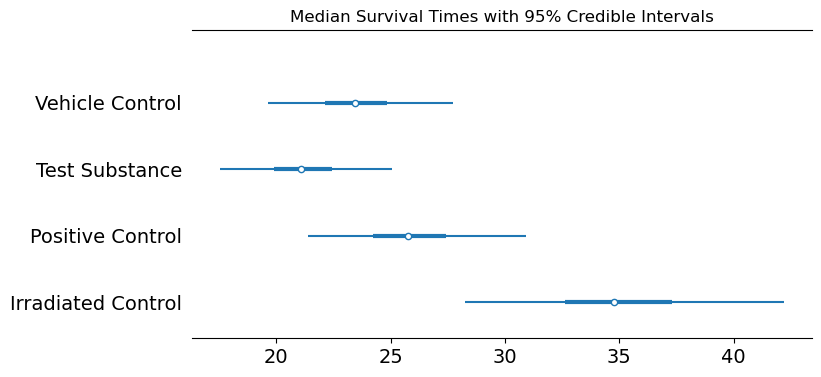

In [22]:
# Plot median survival times with 95% credible intervals
ax = az.plot_forest(
    trace_1,
    var_names=["median_survival"],
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 4),
)
ax[0].set_title("Median Survival Times with 95% Credible Intervals")
ax[0].set_yticklabels(group_names)

In [23]:
az.summary(trace_1, round_to=3, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_log__,1.035,0.108,0.824,1.243,0.001,0.000,37091.006,28367.693,1.0
beta[0],-3.286,0.085,-3.460,-3.125,0.000,0.000,46515.536,31691.024,1.0
beta[1],-3.183,0.089,-3.359,-3.011,0.000,0.000,50287.811,29627.121,1.0
beta[2],-3.381,0.091,-3.563,-3.203,0.000,0.000,49893.866,30857.286,1.0
beta[3],-3.685,0.102,-3.882,-3.485,0.000,0.001,45427.547,28147.751,1.0
...,...,...,...,...,...,...,...,...,...
contrast_median_survival[Test Substance - Vehicle Control],-9.207,4.353,-17.842,-0.761,0.021,0.024,44639.284,29557.554,1.0
survival_at_30[0],0.255,0.079,0.111,0.415,0.000,0.000,50210.488,31321.106,1.0
survival_at_30[1],0.164,0.074,0.039,0.312,0.000,0.000,49841.791,30005.886,1.0
survival_at_30[2],0.348,0.090,0.179,0.529,0.000,0.000,50695.163,31130.094,1.0


In [ ]:
# Summarise and plot contrasts
contrast_summary = az.summary(trace_1, var_names="contrast_median_survival", round_to=3, hdi_prob=0.95)
contrast_summary


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
contrast_median_survival[Irradiated Control - Positive Control],2.313,2.760,-3.247,7.703,0.013,0.014,46168.088,29640.652,1.0
contrast_median_survival[Irradiated Control - Test Substance],-2.361,3.088,-8.487,3.668,0.014,0.016,48343.240,29633.938,1.0
contrast_median_survival[Irradiated Control - Vehicle Control],-11.569,4.156,-19.957,-3.724,0.020,0.023,43151.504,28030.005,1.0
contrast_median_survival[Positive Control - Test Substance],-4.674,3.060,-10.671,1.424,0.014,0.016,49003.135,32547.110,1.0
contrast_median_survival[Positive Control - Vehicle Control],-13.881,4.097,-22.324,-6.355,0.020,0.022,44605.013,29039.971,1.0
contrast_median_survival[Test Substance - Vehicle Control],-9.207,4.353,-17.842,-0.761,0.021,0.024,44639.284,29557.554,1.0


Text(0.5, 0, 'Difference in Beta Coefficients')

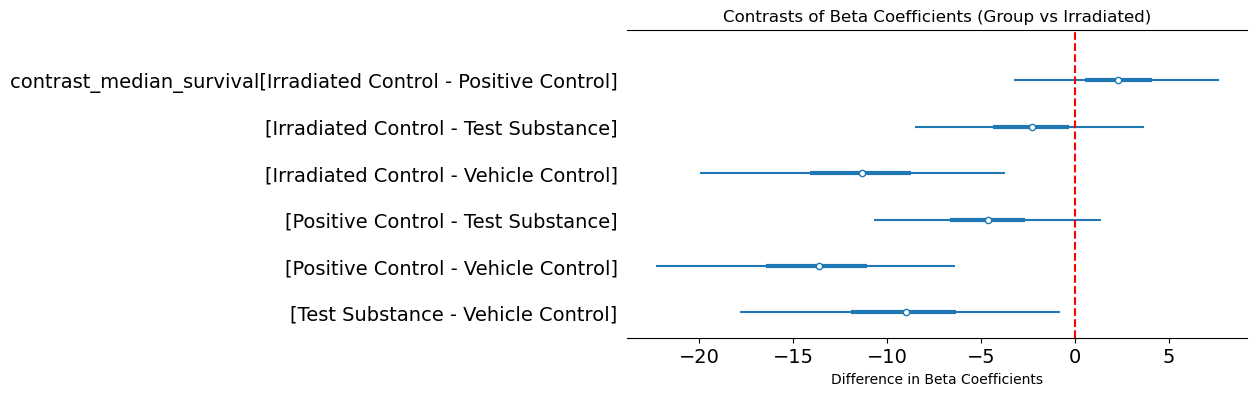

In [38]:
az.plot_forest(
    trace_1,
    var_names="contrast_median_survival",
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 4),
)
plt.title("Contrasts of Beta Coefficients (Group vs Irradiated)")
#plt.yticks(ticks=range(len(irradiated_contrast_names)), labels=irradiated_contrast_names)
# Add vertical line at zero for reference
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Difference in Beta Coefficients")

In [39]:
# Estimate survival for mouse when weeks, t=30 for each group
survival_t_30 = az.summary(trace_1, var_names=["survival_at_30"], round_to=3, hdi_prob=0.95)
survival_t_30

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
survival_at_30[0],0.255,0.079,0.111,0.415,0.0,0.0,50210.488,31321.106,1.0
survival_at_30[1],0.164,0.074,0.039,0.312,0.0,0.0,49841.791,30005.886,1.0
survival_at_30[2],0.348,0.090,0.179,0.529,0.0,0.0,50695.163,31130.094,1.0
survival_at_30[3],0.631,0.081,0.468,0.781,0.0,0.0,50883.074,31482.318,1.0


([<matplotlib.axis.YTick at 0x26ddc0f0e10>,
 [Text(0, 0, 'Irradiated Control'),
  Text(0, 1, 'Positive Control'),
  Text(0, 2, 'Test Substance'),
  Text(0, 3, 'Vehicle Control')])

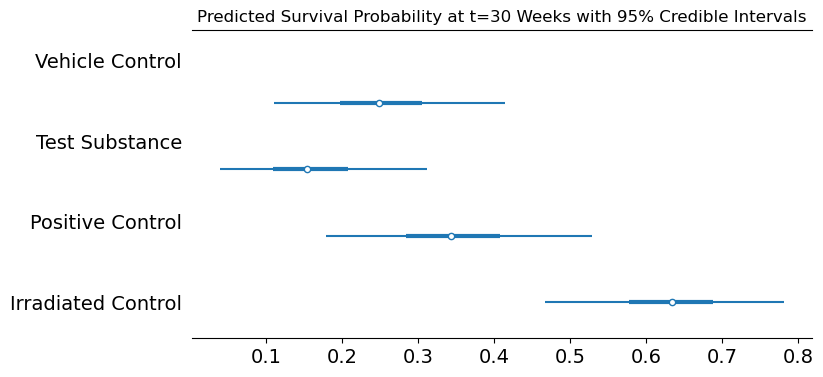

In [40]:
# plot forest plot for survival at t=30 weeks
az.plot_forest(
    trace_1,
    var_names=["survival_at_30"],
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 4),
)
plt.title("Predicted Survival Probability at t=30 Weeks with 95% Credible Intervals")
plt.yticks(ticks=range(4), labels=group_names)

## Question 2

In [247]:
hockpend_data = pd.read_csv("data/hockpend.csv")
hockpend_data.head()


,x1,x2,x3,y
0,12.980,0.317,9.998,57.702
1,14.295,2.028,6.776,59.295
2,15.531,5.305,2.947,55.166
3,15.133,4.738,4.201,55.767
4,15.342,7.038,2.053,51.722


In [248]:
y = hockpend_data["y"].to_numpy(copy=True)
X = hockpend_data[["x1", "x2", "x3"]].to_numpy(copy=True)
n, p = X.shape
print(f"Number of observations: {n}, Number of predictors: {p}")

Number of observations: 26, Number of predictors: 3


In [267]:
# Add intercept column
X_aug = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
n, p = X_aug.shape
print(f"Number of observations: {n}, Number of predictors (including intercept): {p}")
# Zellner's g
g = p ** 2

mu_beta = np.zeros(p)

with pm.Model() as model_2:
    X_data = pm.Data("X", X_aug)
    y_data = pm.Data("y", y)
    
    tau = pm.Gamma("tau", 0.01, 0.01)
    variance = pm.Deterministic("variance", 1 / tau)

    tau_beta = (tau / g) * pm.math.dot(X_aug.T, X_aug)
    beta = pm.MvNormal("beta", mu=mu_beta, tau=tau_beta, shape=p)

    mu = pm.Deterministic("mu", pm.math.dot(X_data, beta))
    likelihood = pm.Normal("likelihood", mu=mu, tau=tau, observed=y)

    trace_2 = pm.sample(10000, tune=2000, nuts_sampler="nutpie")
    pm.compute_log_likelihood(trace_2)

az.summary(trace_2, var_names=["beta", "variance"], round_to=3, hdi_prob=0.95)

Number of observations: 26, Number of predictors (including intercept): 4


d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,1,0.23,63
,12000,0,0.23,63
,12000,1,0.24,7
,12000,0,0.23,7


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],8.701,47.203,-83.158,103.591,0.596,0.489,6292.646,7245.827,1.0
beta[1],3.195,2.707,-2.034,8.604,0.034,0.027,6419.884,7655.452,1.0
beta[2],-1.365,1.197,-3.729,0.979,0.011,0.007,12813.728,17779.472,1.0
beta[3],0.304,1.338,-2.272,3.001,0.014,0.010,9233.041,12571.761,1.0
variance,190.202,57.471,96.946,303.920,0.364,0.468,26515.093,22677.744,1.0


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'variance'}>,
        <Axes: title={'center': 'variance'}>]], dtype=object)

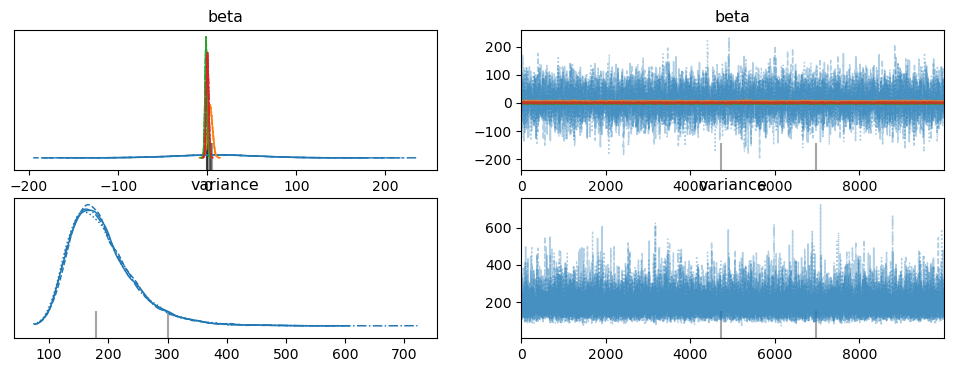

In [268]:
# plot trace
az.plot_trace(trace_2, var_names=["beta", "variance"])

Added a prior on intercept as model is not performing well. Required splitting slope and intercept to set different priors on them.

In [269]:
# Add intercept column
X_aug = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
X_slopes = X_aug[:, 1:]
n, p = X_aug.shape
print(f"Number of observations: {n}, Number of predictors (including intercept): {p}")
# Zellner's g
g = p ** 2

mu_beta = np.zeros(p-1)

with pm.Model() as model_2:
    X_data = pm.Data("X", X_aug)
    y_data = pm.Data("y", y)
    
    tau = pm.Gamma("tau", 0.01, 0.01)
    variance = pm.Deterministic("variance", 1 / tau)

    # Intercept
    beta0 = pm.Normal("beta0", mu=0, sigma=1000)
    # Slopes
    tau_beta = (tau / g) * pm.math.dot(X_slopes.T, X_slopes)
    beta_slopes = pm.MvNormal("beta_slopes", mu=mu_beta, tau=tau_beta, shape=p-1)
    beta = pm.Deterministic("beta", pt.concatenate([[beta0], beta_slopes]))

    mu = pm.math.dot(X_data, beta)
    likelihood = pm.Normal("likelihood", mu=mu, tau=tau, observed=y)

    trace_2_update = pm.sample(10000, tune=2000, nuts_sampler="nutpie")
    pm.compute_log_likelihood(trace_2_update)

Number of observations: 26, Number of predictors (including intercept): 4


d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.39,15
,12000,0,0.40,7
,12000,0,0.41,31
,12000,0,0.38,7


Output()

In [270]:
az.summary(trace_2_update, round_to=3, var_names=["beta", "variance"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],51.240,2.976,45.436,57.148,0.025,0.019,13884.684,17468.019,1.0
beta[1],0.973,0.217,0.544,1.404,0.002,0.001,12379.614,15797.122,1.0
beta[2],-1.883,0.288,-2.461,-1.322,0.002,0.002,19133.848,21253.967,1.0
beta[3],-0.546,0.247,-1.041,-0.063,0.002,0.001,22907.477,24780.461,1.0
variance,14.762,4.587,7.256,23.739,0.028,0.036,28100.969,23688.248,1.0


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'variance'}>,
        <Axes: title={'center': 'variance'}>]], dtype=object)

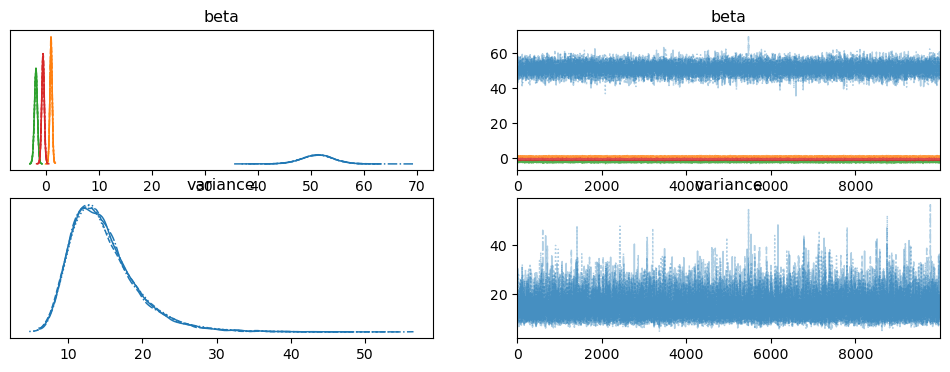

In [276]:
az.plot_trace(trace_2_update, var_names=["beta", "variance"])

Sampling: [likelihood]


Output()

<Axes: xlabel='likelihood'>

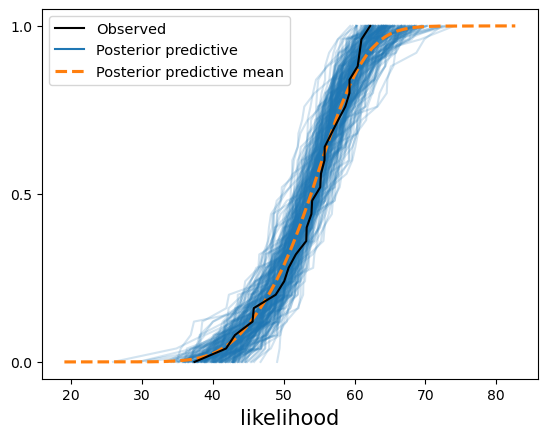

In [275]:
# R2 score for linear regression for each predictor
ppc_2 = pm.sample_posterior_predictive(
    trace_2_update, model=model_2, random_seed=rng, var_names=["likelihood"], extend_inferencedata=True   
    )
az.plot_ppc(ppc_2, kind="cumulative", num_pp_samples=200)

#### 2b) Finding outliers

In [277]:
def evaluate_ecdf(trace: az.InferenceData) -> np.array:
    """Evaluates ECDF at original observed values.

    This function assumes a single set of observed values.

    Args:
        trace: arviz.InferenceData from running a PyMC model.

    Returns:
        A Numpy array of the ECDF evaluation at each original datapoint.
    """
    # get posterior predictive variable name
    ppc_vars = list(trace.posterior_predictive.data_vars)
    assert (
        len(ppc_vars) == 1
    ), "Number of variables in posterior predictive must equal 1."
    y_varname = ppc_vars[0]

    # get original observations
    y_obs = trace.observed_data[y_varname].values
    assert (
        len(y_obs.shape) == 1
    ), "Y-observations shape must be one-dimensional."
    n_obs = y_obs.shape[0]
    y_obs = y_obs.reshape(-1, 1)  # for broadcasting

    # get posterior predictive samples for each y_obs and sample count
    y_samples_per_obs = trace.posterior_predictive[y_varname].stack(
        sample=("chain", "draw")
    )
    assert y_samples_per_obs.shape[0] == n_obs, "Shape assumptions aren't met."
    n_samples = y_samples_per_obs.shape[1]

    # evaluate ECDF at each y_obs and convert to numpy array
    ecdf_values = y_samples_per_obs <= y_obs
    prob = ecdf_values.sum(dim="sample") / n_samples

    return prob.to_numpy()

In [278]:
prob_ecdf_pit = evaluate_ecdf(trace_2_update)
loo_pit_output = az.loo_pit(trace_2_update, y="likelihood")
df_results = pd.DataFrame(
    {"likelihood": y, "loo_pit": loo_pit_output, "ecdf_pit": prob_ecdf_pit}
)
df_results["squared_logit"] = np.log(prob_ecdf_pit / (1 - prob_ecdf_pit)) ** 2

df_display = df_results.sort_values(by="squared_logit", ascending=False)
df_display

,likelihood,loo_pit,ecdf_pit,squared_logit
23,56.741,0.999767,0.990125,21.232050
14,53.254,0.017635,0.038075,10.428886
17,50.086,0.108404,0.134475,3.466887
16,58.699,0.873103,0.861850,3.351613
7,37.447,0.085097,0.142925,3.208417
5,60.446,0.855447,0.825525,2.415656
19,62.213,0.833313,0.809475,2.092659
13,41.896,0.188196,0.221275,1.583197
8,60.974,0.799901,0.770075,1.461040
24,43.145,0.220950,0.246700,1.246105


Text(0.5, 1.0, 'Posterior Predictive Check: Observed vs Predicted Values')

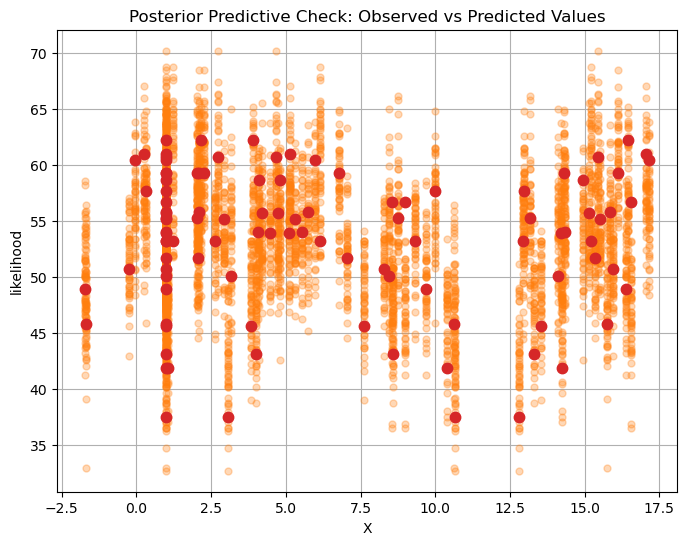

In [279]:
az.plot_lm(
    idata=trace_2_update,
    y="likelihood",
    x="X",
    figsize=(8, 6),
    legend=False,
)
plt.title("Posterior Predictive Check: Observed vs Predicted Values")


#### 2c) Two Robust Models built, one where $\nu$ is an exponential (less informative) and one where $\nu$ is a gamma distribution (more informative, favoring heavier tails)

In [ ]:
# Build a more robust model by adding a Student's t likelihood
with pm.Model() as model_2_robust_v1:
    X_data = pm.Data("X_shared", X_aug)
    y_data = pm.Data("y_shared", y)

    tau = pm.Gamma("tau", 0.01, 0.01)
    variance = pm.Deterministic("variance", 1 / tau)

    # Intercept
    beta0 = pm.Normal("beta0", mu=0, sigma=1000)
    # Slopes
    tau_beta = (tau / g) * pm.math.dot(X_slopes.T, X_slopes)
    beta_slopes = pm.MvNormal("beta_slopes", mu=mu_beta, tau=tau_beta, shape=p-1)
    beta = pm.Deterministic("beta", pt.concatenate([[beta0], beta_slopes]))

    mu = pm.Deterministic("mu", pm.math.dot(X_data, beta))
    nu = pm.Exponential("nu", 1/30)
    likelihood = pm.StudentT("likelihood", mu=mu, sigma=pm.math.sqrt(variance), nu=nu, observed=y)

    # New observations for prediction
    X_new = pm.Data("X_new", np.array([[10, 5, 4]]))  # Define new data container for predictions
    mr = pm.Deterministic("mu_response", pm.math.dot(X_new, beta))
    pm.StudentT("predictive_response", mu=mr, sigma=pm.math.sqrt(variance), nu=nu)  # Define predictive distribution for new observation

    # Sampling
    trace_2_robust_v1 = pm.sample(10000, tune=2000, nuts_sampler="nutpie")
    ppc_2_robust_v1 = pm.sample_posterior_predictive(
        trace_2_robust_v1, random_seed=rng, extend_inferencedata=True
    )
    pm.compute_log_likelihood(trace_2_robust_v1)

az.summary(trace_2_robust_v1, var_names=["beta", "variance", "nu"], round_to=3, hdi_prob=0.95)

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.40,15
,12000,0,0.36,31
,12000,0,0.35,7
,12000,0,0.41,31


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],51.980,2.689,46.507,57.189,0.022,0.019,14538.690,16273.011,1.0
beta[1],1.041,0.204,0.622,1.428,0.002,0.001,11449.814,14841.903,1.0
beta[2],-2.103,0.321,-2.729,-1.481,0.003,0.002,11987.954,15596.396,1.0
beta[3],-0.715,0.262,-1.207,-0.181,0.002,0.001,14367.546,19515.647,1.0
variance,11.028,4.575,3.473,19.770,0.034,0.030,15234.376,14214.230,1.0
nu,20.868,24.676,0.805,71.360,0.163,0.237,16628.687,21352.159,1.0


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'variance'}>,
        <Axes: title={'center': 'variance'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>]],
      dtype=object)

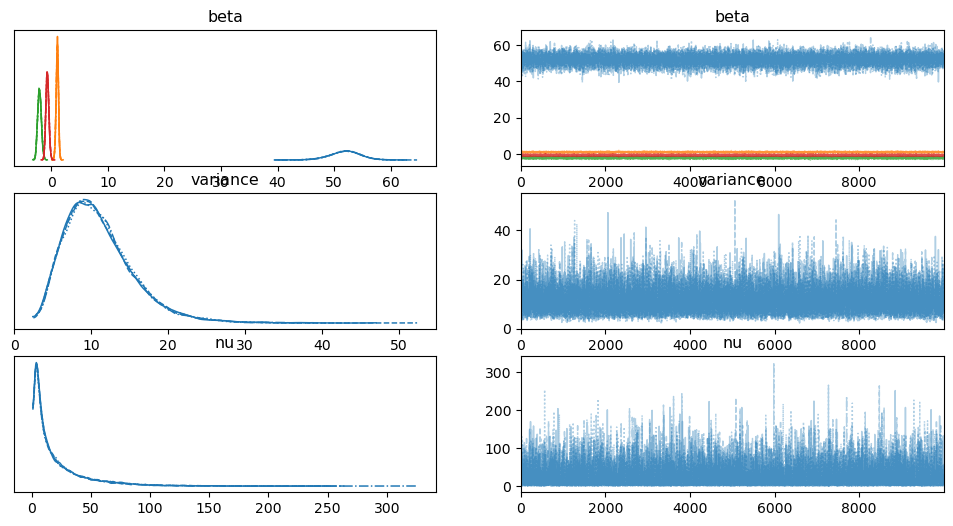

In [281]:
# plot trace for robust model
az.plot_trace(trace_2_robust_v1, var_names=["beta", "variance", "nu"])

In [ ]:
# Same model but adjust prior on nu to be more informative and a different distribution
with pm.Model() as model_2_robust_v2:
    X_data = pm.Data("X_shared", X_aug)
    y_data = pm.Data("y_shared", y)

    tau = pm.Gamma("tau", 0.01, 0.01)
    variance = pm.Deterministic("variance", 1 / tau)

    # Intercept
    beta0 = pm.Normal("beta0", mu=0, sigma=1000)
    # Slopes
    tau_beta = (tau / g) * pm.math.dot(X_slopes.T, X_slopes)
    beta_slopes = pm.MvNormal("beta_slopes", mu=mu_beta, tau=tau_beta, shape=p-1)
    beta = pm.Deterministic("beta", pt.concatenate([[beta0], beta_slopes]))

    mu = pm.Deterministic("mu", pm.math.dot(X_data, beta))
    nu = pm.Gamma("nu", alpha=2, beta=0.1)  # More informative prior favoring heavier tails

    likelihood = pm.StudentT("likelihood", mu=mu, sigma=pm.math.sqrt(variance), nu=nu, observed=y)

    # New observations for prediction
    X_new = pm.Data("X_new", np.array([[10, 5, 4]]))  # Define new data container for predictions
    mr = pm.Deterministic("mu_response", pm.math.dot(X_new, beta))
    pm.StudentT("predictive_response", mu=mr, sigma=pm.math.sqrt(variance), nu=nuD)  # Define predictive distribution for new observation

    # Sampling
    trace_2_robust_v2 = pm.sample(10000, tune=2000, nuts_sampler="nutpie")
    ppc_2_robust_v2 = pm.sample_posterior_predictive(
        trace_2_robust_v2, random_seed=rng, extend_inferencedata=True
    )
    pm.compute_log_likelihood(trace_2_robust_v2)

az.summary(trace_2_robust_v2, var_names=["beta", "variance", "nu"], round_to=3, hdi_prob=0.95)

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.36,19
,12000,0,0.43,31
,12000,0,0.33,15
,12000,0,0.37,31


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],51.961,2.695,46.620,57.277,0.022,0.021,15142.360,17219.301,1.0
beta[1],1.039,0.202,0.633,1.427,0.002,0.001,13055.585,16537.883,1.0
beta[2],-2.098,0.308,-2.688,-1.489,0.003,0.002,14016.862,17339.462,1.0
beta[3],-0.711,0.257,-1.212,-0.205,0.002,0.001,17538.504,21716.589,1.0
variance,11.016,4.310,3.826,19.440,0.031,0.030,16936.375,14583.276,1.0
nu,15.283,12.378,1.202,40.195,0.076,0.087,20648.392,20676.186,1.0


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'variance'}>,
        <Axes: title={'center': 'variance'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>]],
      dtype=object)

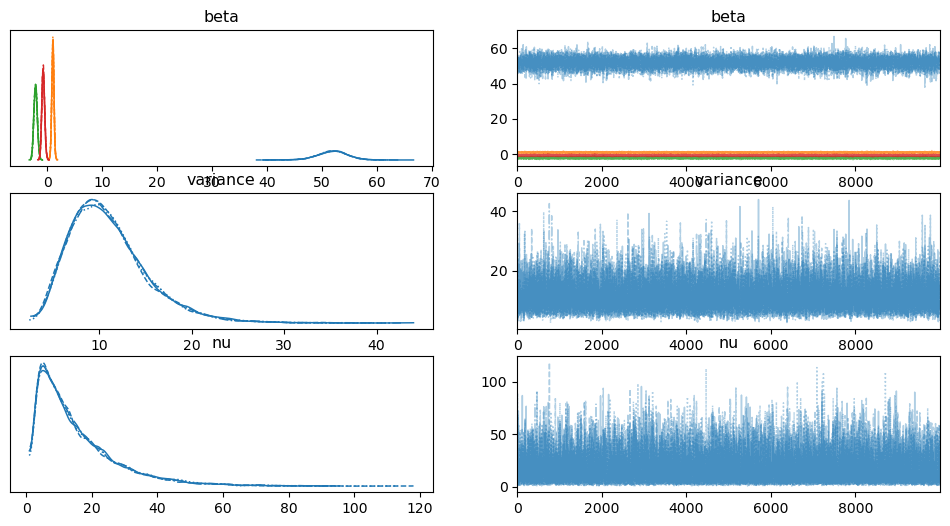

In [283]:
# Plot trace
az.plot_trace(trace_2_robust_v2, var_names=["beta", "variance", "nu"])

In [284]:
# Use PSIS-LOO to compare the original model with the two robust versions
loo_original = az.loo(trace_2, pointwise=True)
loo_robust_v1 = az.loo(trace_2_robust_v1, pointwise=True)
loo_robust_v2 = az.loo(trace_2_robust_v2, pointwise=True)
loo_comparison = az.compare(
    {"Original": trace_2, "Robust_v1": trace_2_robust_v1, "Robust_v2": trace_2_robust_v2},
)
loo_comparison

d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\stats.py:782: UserW

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Robust_v1,0,-71.714544,5.152679,0.000000,0.000000,6.093419,0.000000,True,log
Robust_v2,1,-71.744924,5.087308,0.030380,0.964273,6.190509,0.115397,True,log
Original,2,-95.794480,1.715066,24.079936,0.035727,1.071914,5.159918,True,log


#### 2d) Mean response at new data point

In [95]:
az.summary(ppc_2_robust_v1, var_names=["mu_response", "predictive_response"], round_to=3, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_response[0],34.886,0.289,34.278,35.414,0.002,0.002,14718.035,17155.835,1.0
predictive_response[0],34.943,2.926,30.485,39.370,0.043,0.294,16890.406,7517.843,1.0


## Question 3

In [92]:
milling_data = pd.read_csv("data/millingmiss.csv")
milling_data.head()

,Hardness,Rake,Helix,Relief,Corner,Flute,force
0,0.000000,0.8326,0.461583,0.966667,0.1560,0.168333,542.4469
1,0.006133,0.5642,0.744583,0.725000,0.5614,0.561667,548.4845
2,0.015600,0.1916,0.206667,0.415500,0.4528,0.828333,NaN
3,0.022133,0.7510,0.321250,0.000000,0.8804,0.371667,601.0511
4,0.030567,0.0824,0.985500,0.540333,0.0372,0.418333,498.5836


In [93]:
y = milling_data["force"].to_numpy(copy=True)
X = milling_data.drop(columns=["force"]).to_numpy(copy=True)

# Check for missing values in X
print("Missing values in X:", np.isnan(X).sum())

Missing values in X: 0


In [150]:
chains = 4
draws = 10000
rows = chains * draws

In [162]:
# Assume MCAR missingness and fit a linear regression model
with pm.Model() as model_milling_mcar:
    X_data = pm.Data("X", X)
    beta = pm.Normal("beta", mu=0, sigma=100, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 1/100)                          # Standard deviation is 1/lambda
    mu = pm.Deterministic("mu", pm.math.dot(X_data, beta))
    
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y)

    trace_milling_mcar = pm.sample(draws, tune=2000, chains=chains, nuts_sampler="nutpie")
    ppc_mcar = pm.sample_posterior_predictive(trace_milling_mcar, extend_inferencedata=True)

az.summary(trace_milling_mcar, var_names=["sigma", "likelihood"], round_to=3, hdi_prob=0.95)

d:\anaconda3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in likelihood contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.48,7
,12000,0,0.45,7
,12000,0,0.50,7
,12000,0,0.52,15


Sampling: [likelihood_observed]


Output()

d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
d:\anacon

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,167.660,19.281,131.902,206.050,0.128,0.099,22757.122,27042.224,1.0
likelihood[0],542.447,0.000,542.447,542.447,0.000,NaN,40000.000,40000.000,NaN
likelihood[1],548.484,0.000,548.484,548.484,0.000,0.000,40000.000,40000.000,NaN
likelihood[2],329.359,175.175,-13.134,674.720,0.791,0.929,49104.898,30311.208,1.0
likelihood[3],601.051,0.000,601.051,601.051,0.000,0.000,40000.000,40000.000,NaN
...,...,...,...,...,...,...,...,...,...
likelihood[55],670.075,182.494,305.487,1024.892,0.890,0.962,42111.938,28800.313,1.0
likelihood[56],684.232,0.000,684.232,684.232,0.000,0.000,40000.000,40000.000,NaN
likelihood[57],642.301,0.000,642.301,642.301,0.000,0.000,40000.000,40000.000,NaN
likelihood[58],715.350,0.000,715.350,715.350,0.000,0.000,40000.000,40000.000,NaN


<Axes: xlabel='likelihood_observed'>

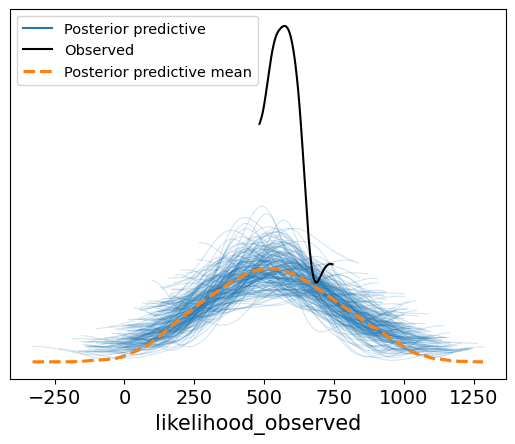

In [173]:
# Plot posterior predictive for the MCAR model
az.plot_ppc(ppc_mcar, kind="kde", num_pp_samples=200)

In [164]:
az.summary(trace_milling_mcar, var_names=["likelihood"], round_to=3, hdi_prob=0.95)

d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
d:\anacon

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
likelihood[0],542.447,0.000,542.447,542.447,0.000,NaN,40000.000,40000.000,NaN
likelihood[1],548.484,0.000,548.484,548.484,0.000,0.000,40000.000,40000.000,NaN
likelihood[2],329.359,175.175,-13.134,674.720,0.791,0.929,49104.898,30311.208,1.0
likelihood[3],601.051,0.000,601.051,601.051,0.000,0.000,40000.000,40000.000,NaN
likelihood[4],498.584,0.000,498.584,498.584,0.000,NaN,40000.000,40000.000,NaN
likelihood[5],509.446,0.000,509.446,509.446,0.000,0.000,40000.000,40000.000,NaN
likelihood[6],409.865,176.588,56.542,751.513,0.797,0.920,49047.472,31048.726,1.0
likelihood[7],502.343,0.000,502.343,502.343,0.000,NaN,40000.000,40000.000,NaN
likelihood[8],444.059,178.022,95.470,795.995,0.848,0.933,44120.593,31061.206,1.0
likelihood[9],581.146,0.000,581.146,581.146,0.000,NaN,40000.000,40000.000,NaN


#### 3b)

In [165]:
# Mask y nan values
y_masked = np.ma.masked_invalid(y)
# Change nan values to -1
y_masked = np.ma.masked_values(y_masked, value=-1)
miss = y_masked.mask
miss

array([False, False,  True, False, False, False,  True, False,  True,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False,  True, False, False, False,  True, False,
       False, False,  True, False, False,  True, False, False, False,
        True, False,  True, False, False, False, False, False,  True,
        True, False, False, False, False, False,  True, False, False,
       False,  True, False, False, False,  True])

In [180]:
# Assume MNAR for the same model ( 50% chance of missingness when y=650, increasing by 0.1 for every 1 unit increase in y and vice versa) and fit the model again
t = 0.1
b = 0.1

with pm.Model() as model_milling_mnar:
    X_data = pm.Data("X", X)
    # log odds increase of missingness by 0.1 for every 1 unit
    a = pm.Logistic("a", mu=0, s=1/t)
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=100, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 1/100)                        
    mu = pm.Deterministic("mu", pm.math.dot(X, beta))

    y_imputed = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y_masked)

    # Missingness model
    p = pm.Deterministic("p", pm.math.invlogit(a + b * (y_imputed - 650)))
    pm.Bernoulli("missingness", p=p, observed=miss)

    trace_milling_mnar = pm.sample(10000, tune=4000, nuts_sampler="nutpie")
    ppc_mnar = pm.sample_posterior_predictive(trace_milling_mnar, extend_inferencedata=True)

d:\anaconda3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in likelihood contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,14000,0,0.28,31
,14000,0,0.26,15
,14000,0,0.26,15
,14000,0,0.27,15


Sampling: [likelihood_observed, missingness]


Output()

In [181]:
az.summary(trace_milling_mnar, var_names=["sigma", "a"], round_to=3, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,216.089,25.621,168.818,267.024,0.210,0.143,15315.075,22224.325,1.0
a,-9.179,1.652,-12.435,-6.067,0.011,0.012,24095.872,19496.771,1.0


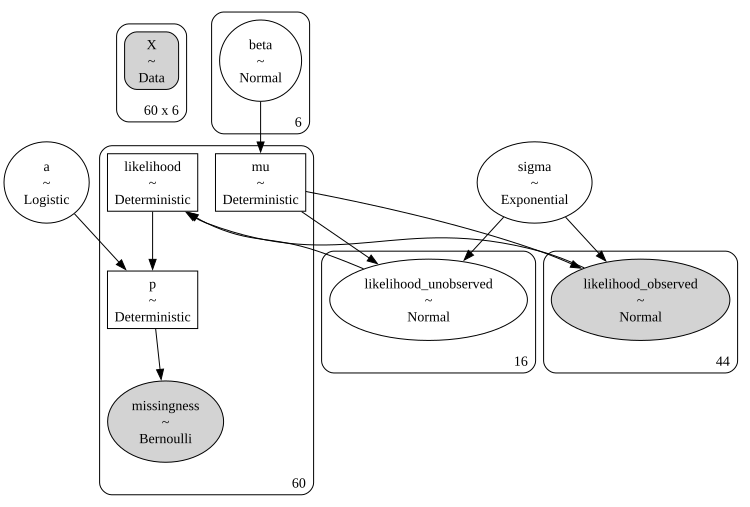

In [182]:
pm.model_to_graphviz(model_milling_mnar)

In [183]:
# Compute R2 score for the MCAR model
y_pred_mnar = ppc_mnar.posterior_predictive.stack(sample=("chain", "draw"))["likelihood"].values.T
az.r2_score(y, y_pred_mnar)

r2       NaN
r2_std   NaN
dtype: float64

#### 3c)

In [184]:
# Find values that minimise posterior mean
posterior_mean = ppc_mnar.posterior_predictive.stack(sample=("chain", "draw"))["likelihood"].mean(dim="sample").values
min_index = np.argmin(posterior_mean)
min_value = posterior_mean[min_index]
print(f"Minimum posterior mean value: {min_value} at index {min_index}")
# Get corresponding X values for the minimum posterior mean
X_min = X[min_index]
# Assign labels to the minimum X values
feature_names = milling_data.drop(columns=["force"]).columns
X_min_dict = {feature_names[i]: X_min[i] for i in range(len(feature_names))}
print("X values corresponding to minimum posterior mean:")
for feature, value in X_min_dict.items():
    print(f"{feature}: {value}")


Minimum posterior mean value: 248.49083964606882 at index 18
X values corresponding to minimum posterior mean:
Hardness: 0.2549
Rake: 0.5434
Helix: 0.22125
Relief: 0.248833333
Corner: 0.0166
Flute: 0.07833333


In [188]:
# Run prediction wihtin model for the minimum X values
t = 0.1
b = 0.1

with pm.Model() as model_milling_mnar:
    X_data = pm.Data("X", X)
    # log odds increase of missingness by 0.1 for every 1 unit
    a = pm.Logistic("a", mu=0, s=1/t)
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=100, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 1/100)                        
    mu = pm.Deterministic("mu", pm.math.dot(X, beta))

    y_imputed = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y_masked)

    # Missingness model
    p = pm.Deterministic("p", pm.math.invlogit(a + b * (y_imputed - 650)))
    pm.Bernoulli("missingness", p=p, observed=miss)

    # Prediction for minimum X values
    X_new = pm.Data("X_new", X_min.reshape(1, -1))
    mu_new = pm.Deterministic("mu_new", pm.math.dot(X_new, beta))
    y_new = pm.Normal("prediction", mu=mu_new, sigma=sigma)


    trace_milling_mnar = pm.sample(10000, tune=4000, nuts_sampler="nutpie")
    ppc_mnar = pm.sample_posterior_predictive(trace_milling_mnar, extend_inferencedata=True)

az.summary(ppc_mnar, var_names=["prediction"], round_to=3, hdi_prob=0.95)

d:\anaconda3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in likelihood contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,14000,0,0.27,15
,14000,0,0.26,15
,14000,0,0.26,15
,14000,0,0.28,15


Sampling: [likelihood_observed, missingness]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
prediction[0],247.952,219.398,-180.219,679.922,0.988,1.253,49344.096,27745.204,1.0
